In [ ]:
import rte
import vegas_params as vp
import numpy as np
import scipy
import gvar

In [2]:
import matplotlib.pyplot as plt

# Define the setup
## Light source
Isotropic laser, shining from the coordinates `(0,0,0)`

In [3]:
#define the light source
from laser import Laser

src = Laser(position=[0,0,0],
            time=0,
            direction=vp.Direction(0., phi=-np.pi/2),
            # direction=vp.Direction(),#1.,0),
            diffuser_sigma=0.1,
            total_photons=1e15
           )

Normalizing norm=6.28318530717959(15) to value=1000000000000000.0 with norm_factor=159154943091895.34


## Detectors
Spherical optical modules, distributed within a sperical volume 

In [4]:
#define the detector
from detector import BGVD_Module
tgt = BGVD_Module(
    center=vp.Vector([0,0,0]),
    T = vp.Uniform([400e-9,5000e-9])#
)

Npoints = 1000
positions = (vp.Direction()*vp.Uniform([500,3000])).sample(Npoints)
R = positions.mag().squeeze()

In [ ]:
rte_w

In [5]:
laser_wavelength = 532 #nm

#define the water medium
import medium
rte_water = medium.get_properties(laser_wavelength)
rte_water.mu_a*=0
rte_water

Medium(mu_a=np.float64(0.0), mu_s=np.float64(0.013999999999999999), c=np.float64(224247570.15699768), g=0.9)

In [6]:
#expected light
r_OM = tgt['radius'].sample()
# r = np.arange(R.min(),R.max(), 501)
L_exp = 1e15 * (np.pi*r_OM**2)/(4*np.pi) / R**2 * rte_water.attenuation(R/rte_water.c, n_scattering=0)
L_exp = L_exp.squeeze()

In [7]:
tgt = rte.detectors.DetectorSpherical(
    center=vp.Vector([0,0,0]),
    T = vp.Uniform([400e-9,5000e-9])
)

## The process object

In [8]:
c = rte.RTECalculator(src=src, tgt=tgt, medium = rte_water)
c.vegas_kwargs = {'nitn':10, 'neval':2000}
#run the calculation

# Calculate with a single "soft" factor

In [9]:
from time import perf_counter
from contextlib import contextmanager

In [10]:
@contextmanager
def measure_time():
    t1 = t2 = perf_counter()
    yield lambda: t2 - t1
    t2 = perf_counter()

In [11]:
results = {}

In [12]:
p = c.get_process(0)
p.vegas_kwargs={'nitn':10, 'neval':10000}
p.vegas_kwargs['adapt_params']={'nitn':10, 'neval':10000}

with measure_time() as t:
    result = p.calculate_map(override={'tgt.center.xyz':positions}, output='reshape')
    L = gvar.mean(result)

params = {**p.vegas_kwargs['adapt_params']}
results[(str(params),t())] = L

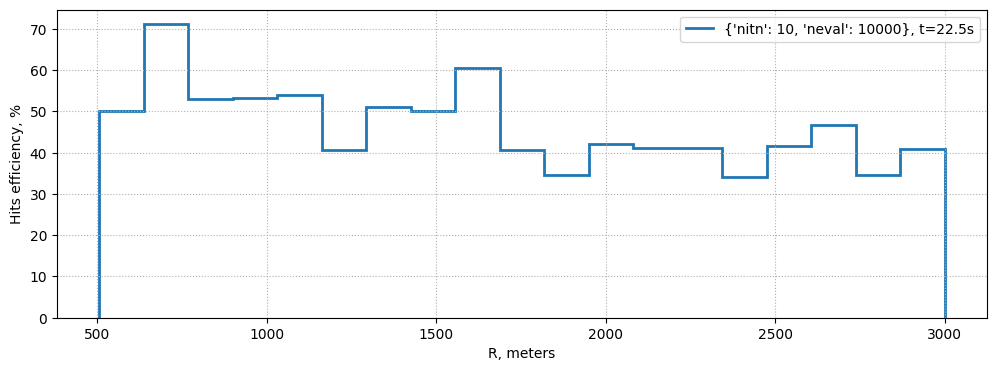

In [13]:
plt.figure(figsize=(12,4))
#efficiency of hits vs.distance:
bins = np.linspace(R.min(), R.max(),20)

for params,L in results.items():
    params,t = params
    N_tot,_ = np.histogram(R, bins)
    N_hit,_ = np.histogram(R, bins, weights=1.*(L>0))
    plt.stairs(N_hit/N_tot*100, bins, label=f'{params}, t={t:2.3g}s', lw=2)

plt.legend()
plt.ylabel('Hits efficiency, %')
plt.xlabel('R, meters')
plt.grid(ls=':')
plt.show()

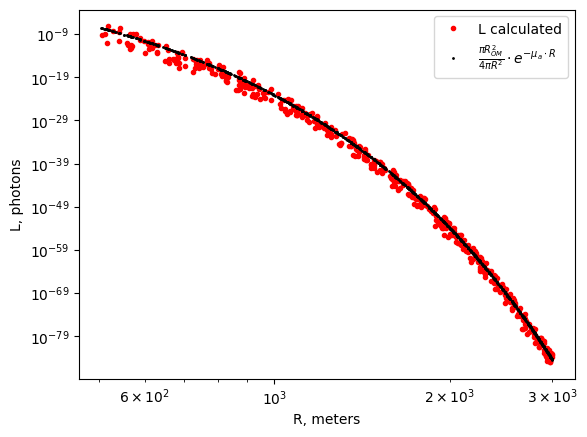

In [14]:
plt.plot(R, L, '.r', label='L calculated')
plt.plot(R, L_exp, '.k', label=r'$\frac{\pi R_{OM}^2}{4\pi R^2} \cdot e^{-\mu_a\cdot R}$', markersize=2)
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.xlabel('R, meters')
plt.ylabel('L, photons')
plt.show()

In [ ]:
кеу_

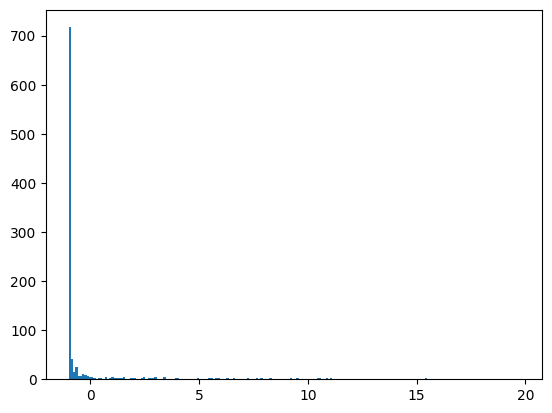

In [15]:
residual = (L-L_exp)/L_exp

plt.hist(residual, bins=200)
plt.show()

# Calculate for many "softness" factors

In [16]:
#run the calculation
def calc_with_soft(soft:float)->float:
    tgt.soften_parameter=soft
    result = p.calculate_map(override={'tgt.center.xyz':positions}, output='reshape')
    #calculated light
    L = gvar.mean(result)
    # R = positions.mag().squeeze()
    return L

In [17]:
from tqdm.auto import tqdm

results = {}
for soft in tqdm(np.geomspace(1e-3, 1e1, 31)):
    results[soft] = calc_with_soft(soft)

/home/ash/work/baikal/venv_dev/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 84%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                             | 26/31 [10:05<01:56, 23.29s/it]Process ForkProcess-218:
Process ForkProcess-221:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 

In [ ]:
s, hits = np.array([(par, np.mean(res>0)) for par, res in results.items()]).T
plt.plot(s, hits)
plt.xscale('log')
plt.xlabel('"Softness" factor, s')
plt.ylabel('Hit efficiency')
plt.grid(ls=':')
plt.show()

In [ ]:
cmap = plt.cm.inferno

bins = np.linspace(R.min(), R.max(),20)
pars = np.array(list(results.keys()))
n = 0
for par, res in results.items():
    N_tot,_ = np.histogram(R, bins)
    N_hit,_ = np.histogram(R, bins, weights=1.*(res!=0))
    plt.plot(N_hit/N_tot, bins[:-1], label=f's={par:2g}', color=cmap(n/pars.size) )
    n+=1
plt.ylabel('Hits efficiency')
plt.xlabel('R, meters')
plt.show()

In [ ]:
np.mean(res!=0)